In [ ]:
import os
from google.colab import drive
# 1. Mount Google Drive (for questions, scene graphs, and saving models)
drive.mount('/content/drive')
# 2. Setup local high-speed directories
os.makedirs('/content/dataset/images', exist_ok=True)
os.makedirs('/content/dataset/questions', exist_ok=True)
# 3. Clean up any broken downloads from previous attempts
!rm -f /content/images.zip
# 4. Download images directly from Stanford to Colab local disk
print("Downloading 20GB images.zip... PLEASE WAIT UNTIL 100%")
!wget -O /content/images.zip https://downloads.cs.stanford.edu/nlp/data/gqa/images.zip
# 5. Unzip images locally
print("Unzipping images... (This takes a few minutes)")
!unzip -q /content/images.zip -d /content/dataset/images
!rm /content/images.zip # Free up 20GB of disk space!
# 6. Unzip questions from your Google Drive
# UPDATE THIS PATH if your questions1.2.zip is in a different Drive folder
print("Unzipping questions from Drive...")
!unzip -q "/content/drive/MyDrive/XVQA_project/raw_data/questions1.2.zip" -d /content/dataset/questions
print("Data setup complete! All files are in /content/dataset/")

Mounted at /content/drive
--2026-04-09 19:24:48--  https://downloads.cs.stanford.edu/nlp/data/gqa/images.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 21817965542 (20G) [application/zip]
Saving to: ‘/content/images.zip’

/content/images.zip 100%[===================>]  20.32G  5.12MB/s    in 70m 18s 

2026-04-09 20:35:06 (4.93 MB/s) - ‘/content/images.zip’ saved [21817965542/21817965542]

Unzipping images... (This takes a few minutes)
Unzipping questions from Drive...
Data setup complete! All files are in /content/dataset/


In [ ]:
!pip install grad-cam opencv-python matplotlib

In [ ]:
import json
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoImageProcessor, AutoTokenizer
from PIL import Image
import os

In [ ]:
import json
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoImageProcessor, AutoTokenizer, SwinModel, ElectraModel
from PIL import Image
from tqdm import tqdm

class MCANLayer(nn.Module):
    def __init__(self, hidden_dim, num_heads=8):
        super().__init__()
        self.text_to_image_attn = nn.MultiheadAttention(embed_dim=hidden_dim, num_heads=num_heads, batch_first=True)
        self.image_to_text_attn = nn.MultiheadAttention(embed_dim=hidden_dim, num_heads=num_heads, batch_first=True)
        self.layer_norm1 = nn.LayerNorm(hidden_dim)
        self.layer_norm2 = nn.LayerNorm(hidden_dim)
        # FFN for text stream
        self.ffn_text = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim * 4),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(hidden_dim * 4, hidden_dim)
        )
        # FFN for image stream
        self.ffn_image = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim * 4),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(hidden_dim * 4, hidden_dim)
        )
        self.layer_norm3 = nn.LayerNorm(hidden_dim)
        self.layer_norm4 = nn.LayerNorm(hidden_dim)

    def forward(self, text_features, image_features):
        # Co-attention
        text_attended, _ = self.text_to_image_attn(query=text_features, key=image_features, value=image_features)
        text_out = self.layer_norm1(text_features + text_attended)

        image_attended, _ = self.image_to_text_attn(query=image_features, key=text_features, value=text_features)
        image_out = self.layer_norm2(image_features + image_attended)

        # FFN sublayer (this is what makes it the real MCAN)
        text_out = self.layer_norm3(text_out + self.ffn_text(text_out))
        image_out = self.layer_norm4(image_out + self.ffn_image(image_out))

        return text_out, image_out
class MCAN(nn.Module):
    def __init__(self, hidden_dim, num_heads=8, num_layers=6):
        super().__init__()
        self.layers = nn.ModuleList([
            MCANLayer(hidden_dim, num_heads) for _ in range(num_layers)
        ])

    def forward(self, text_features, image_features):
        for layer in self.layers:
            text_features, image_features = layer(text_features, image_features)
        return text_features, image_features

class XVQAModel(nn.Module):
    def __init__(self, num_answers, hidden_dim=512):
        super().__init__()
        self.vision_encoder = SwinModel.from_pretrained("microsoft/swin-base-patch4-window7-224")
        self.text_encoder = ElectraModel.from_pretrained("google/electra-base-discriminator")

        self.vision_proj = nn.Linear(self.vision_encoder.config.hidden_size, hidden_dim)
        self.text_proj = nn.Linear(self.text_encoder.config.hidden_size, hidden_dim)

        self.mcan = MCAN(hidden_dim=hidden_dim, num_heads=8, num_layers=6)
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, num_answers)
        )

    def forward(self, pixel_values, input_ids, attention_mask):
        image_features = self.vision_encoder(pixel_values=pixel_values).last_hidden_state
        text_features = self.text_encoder(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state

        image_features = self.vision_proj(image_features)
        text_features = self.text_proj(text_features)

        text_fused, image_fused = self.mcan(text_features, image_features)

        text_pooled = text_fused.mean(dim=1)
        image_pooled = image_fused.mean(dim=1)

        combined_features = torch.cat([text_pooled, image_pooled], dim=1)
        return self.classifier(combined_features)

In [ ]:
class GQADataset(Dataset):
    def __init__(self, questions_json_path, images_dir, answer_to_id):
        with open(questions_json_path, 'r') as f:
            self.questions_data = json.load(f)
        self.question_ids = list(self.questions_data.keys())
        self.images_dir = images_dir

        print("Loading Processors...")
        self.image_processor = AutoImageProcessor.from_pretrained("microsoft/swin-base-patch4-window7-224")
        self.tokenizer = AutoTokenizer.from_pretrained("google/electra-base-discriminator")
        self.answer_to_id = answer_to_id

    def __len__(self):
        return len(self.question_ids)

    def __getitem__(self, idx):
        q_id = self.question_ids[idx]
        q_info = self.questions_data[q_id]

        question_text = q_info['question']
        text_inputs = self.tokenizer(
            question_text, padding='max_length', truncation=True, max_length=40, return_tensors="pt"
        )
        # Try inner folder first (Standard GQA zip format)
        image_path = os.path.join(self.images_dir, "images", f"{q_info['imageId']}.jpg")
        if not os.path.exists(image_path):
            image_path = os.path.join(self.images_dir, f"{q_info['imageId']}.jpg")
        try:
            image = Image.open(image_path).convert('RGB')
        except Exception as e:
            # Fallback to a blank image if one is corrupted
            image = Image.new('RGB', (224, 224))

        pixel_values = self.image_processor(images=image, return_tensors="pt").pixel_values
        label = self.answer_to_id.get(q_info['answer'], 0)

        return {
            'pixel_values': pixel_values.squeeze(0),
            'input_ids': text_inputs['input_ids'].squeeze(0),
            'attention_mask': text_inputs['attention_mask'].squeeze(0),
            'labels': torch.tensor(label, dtype=torch.long)
        }

# Paths
train_questions_path = '/content/dataset/questions/train_balanced_questions.json'
images_dir = '/content/dataset/images'
vocab_save_path = '/content/drive/MyDrive/XVQA_project/vocab/answer_to_id.json'

os.makedirs('/content/drive/MyDrive/XVQA_project/vocab', exist_ok=True)

# Use ONLY this version (saves to Drive for Streamlit later)
def build_vocab(questions_path, save_path):
    print("Extracting all unique answers...")
    with open(questions_path, 'r') as f:
        questions = json.load(f)
    unique_answers = sorted(list(set(q['answer'] for q in questions.values())))
    answer_to_id = {ans: i for i, ans in enumerate(unique_answers)}
    with open(save_path, 'w') as f:
        json.dump(answer_to_id, f)
    print(f"Vocab built with {len(answer_to_id)} unique answers. Saved to {save_path}")
    return answer_to_id

vocab = build_vocab(train_questions_path, vocab_save_path)
NUM_ANSWERS = len(vocab)
print(f"Total Unique Answers: {NUM_ANSWERS}")

train_dataset = GQADataset(train_questions_path, images_dir, vocab)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=4, pin_memory=True)

Extracting all unique answers...
Vocab built with 1833 unique answers. Saved to /content/drive/MyDrive/XVQA_project/vocab/answer_to_id.json
Total Unique Answers: 1833
Loading Processors...


In [ ]:
def evaluate(model, dataloader, device):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Validating"):
            pixel_values = batch['pixel_values'].to(device)
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            logits = model(pixel_values, input_ids, attention_mask)
            preds = logits.argmax(dim=-1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    accuracy = correct / total * 100
    print(f"Validation Accuracy: {accuracy:.2f}%")
    return accuracy

In [ ]:
from torch.optim import AdamW
from transformers import get_cosine_schedule_with_warmup

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on: {device}")

model = XVQAModel(num_answers=NUM_ANSWERS).to(device)
criterion = torch.nn.CrossEntropyLoss()

# ── PHASE CONFIGURATION ──────────────────────────────────────────────
# Phase 1: Epochs 1-3 → Freeze encoders, train MCAN + classifier only
# Phase 2: Epochs 4-5 → Unfreeze all, fine-tune end-to-end with low LR
PHASE1_EPOCHS = 3
PHASE2_EPOCHS = 2
num_epochs = PHASE1_EPOCHS + PHASE2_EPOCHS

def get_phase1_optimizer(model):
    # Freeze both encoders
    for param in model.vision_encoder.parameters():
        param.requires_grad = False
    for param in model.text_encoder.parameters():
        param.requires_grad = False
    print("Phase 1: Encoders FROZEN. Training MCAN + projections + classifier only.")
    trainable = filter(lambda p: p.requires_grad, model.parameters())
    return AdamW(trainable, lr=1e-4, weight_decay=0.01)

def get_phase2_optimizer(model):
    # Unfreeze everything
    for param in model.vision_encoder.parameters():
        param.requires_grad = True
    for param in model.text_encoder.parameters():
        param.requires_grad = True
    print("Phase 2: All layers UNFROZEN. Fine-tuning end-to-end.")
    return AdamW([
        {'params': model.vision_encoder.parameters(), 'lr': 5e-6},
        {'params': model.text_encoder.parameters(),  'lr': 5e-6},
        {'params': model.vision_proj.parameters(),   'lr': 1e-5},
        {'params': model.text_proj.parameters(),     'lr': 1e-5},
        {'params': model.mcan.parameters(),          'lr': 1e-5},
        {'params': model.classifier.parameters(),    'lr': 1e-5},
    ], weight_decay=0.01)

def train_one_epoch(model, dataloader, optimizer, criterion, device, scheduler=None):
    model.train()
    total_loss = 0
    progress_bar = tqdm(dataloader, desc="Training")

    for batch in progress_bar:
        pixel_values = batch['pixel_values'].to(device)
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        optimizer.zero_grad()
        logits = model(pixel_values, input_ids, attention_mask)
        loss = criterion(logits, labels)
        loss.backward()

        # Gradient clipping — prevents exploding gradients in unfrozen transformers
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        if scheduler:
            scheduler.step()

        total_loss += loss.item()
        progress_bar.set_postfix({'loss': f"{loss.item():.4f}"})

    return total_loss / len(dataloader)

os.makedirs('/content/drive/MyDrive/XVQA_project/checkpoints', exist_ok=True)

val_questions_path = '/content/dataset/questions/val_balanced_questions.json'
val_dataset = GQADataset(val_questions_path, images_dir, vocab)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=4, pin_memory=True)

best_accuracy = 0.0
scheduler = None

# ── RESUMING SUPPORT ─────────────────────────────────────────────────
start_epoch = 0  # Change to last completed epoch number if resuming
if start_epoch > 0:
    import glob
    pattern = f"/content/drive/MyDrive/XVQA_project/checkpoints/xvqa_epoch_{start_epoch}_*.pth"
    ckpt_files = glob.glob(pattern)
    if ckpt_files:
        model.load_state_dict(torch.load(ckpt_files[0]))
        print(f"Resumed from: {ckpt_files[0]}")

# ── TRAINING LOOP ─────────────────────────────────────────────────────
for epoch in range(start_epoch, num_epochs):

    # Switch optimizer and scheduler at phase boundaries
    if epoch == 0:
        optimizer = get_phase1_optimizer(model)
        num_steps_p1 = PHASE1_EPOCHS * len(train_loader)
        scheduler = get_cosine_schedule_with_warmup(
            optimizer,
            num_warmup_steps=num_steps_p1 // 10,
            num_training_steps=num_steps_p1
        )
        print(f"Phase 1 scheduler: {num_steps_p1} total steps, {num_steps_p1//10} warmup steps")

    elif epoch == PHASE1_EPOCHS:
        optimizer = get_phase2_optimizer(model)
        num_steps_p2 = PHASE2_EPOCHS * len(train_loader)
        scheduler = get_cosine_schedule_with_warmup(
            optimizer,
            num_warmup_steps=num_steps_p2 // 10,
            num_training_steps=num_steps_p2
        )
        print(f"Phase 2 scheduler: {num_steps_p2} total steps, {num_steps_p2//10} warmup steps")

    phase = 1 if epoch < PHASE1_EPOCHS else 2
    print(f"\n--- Epoch {epoch+1}/{num_epochs} [Phase {phase}] ---")

    avg_loss = train_one_epoch(model, train_loader, optimizer, criterion, device, scheduler)
    print(f"Epoch {epoch+1} | Avg Loss: {avg_loss:.4f}")

    val_acc = evaluate(model, val_loader, device)

    checkpoint_path = f"/content/drive/MyDrive/XVQA_project/checkpoints/xvqa_epoch_{epoch+1}_acc{val_acc:.1f}.pth"
    torch.save(model.state_dict(), checkpoint_path)
    print(f"Checkpoint saved: {checkpoint_path}")

    if val_acc > best_accuracy:
        best_accuracy = val_acc
        best_path = "/content/drive/MyDrive/XVQA_project/checkpoints/best_model.pth"
        torch.save(model.state_dict(), best_path)
        print(f"  *** New best model saved ({val_acc:.2f}%) ***")

Training on: cuda


Loading weights:   0%|          | 0/447 [00:00<?, ?it/s]

SwinModel LOAD REPORT from: microsoft/swin-base-patch4-window7-224
Key               | Status     |  | 
------------------+------------+--+-
classifier.weight | UNEXPECTED |  | 
classifier.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

ElectraModel LOAD REPORT from: google/electra-base-discriminator
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
discriminator_predictions.dense_prediction.bias   | UNEXPECTED |  | 
electra.embeddings_project.bias                   | UNEXPECTED |  | 
discriminator_predictions.dense_prediction.weight | UNEXPECTED |  | 
discriminator_predictions.dense.weight            | UNEXPECTED |  | 
discriminator_predictions.dense.bias              | UNEXPECTED |  | 
electra.embeddings_project.weight                 | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

Validation Accuracy: 54.54%
Checkpoint saved: /content/drive/MyDrive/XVQA_project/checkpoints/xvqa_epoch_4_acc54.5.pth
  *** New best model saved (54.54%) ***

--- Epoch 5/5 [Phase 2] ---


Training: 100%|██████████| 29469/29469 [2:52:22<00:00,  2.85it/s, loss=0.9159]


Epoch 5 | Avg Loss: 0.9698


Validating: 100%|██████████| 4127/4127 [07:38<00:00,  9.01it/s]


Validation Accuracy: 55.32%
Checkpoint saved: /content/drive/MyDrive/XVQA_project/checkpoints/xvqa_epoch_5_acc55.3.pth
  *** New best model saved (55.32%) ***


In [ ]:
import zipfile

# Unzip GQA-OOD from Drive
ood_zip = '/content/drive/MyDrive/XVQA_project/raw_data/GQA-OOD-master.zip'
ood_extract_path = '/content/ood/'
with zipfile.ZipFile(ood_zip, 'r') as z:
    z.extractall(ood_extract_path)
print("GQA-OOD extracted.")

# The OOD benchmark provides val questions split by frequency
# Path inside GQA-OOD-master: data/val_all_questions.json or similar
# Check actual structure:
import os
for root, dirs, files in os.walk(ood_extract_path):
    for f in files:
        print(os.path.join(root, f))

GQA-OOD extracted.
/content/ood/GQA-OOD-master/README.md
/content/ood/GQA-OOD-master/code/utils.py
/content/ood/GQA-OOD-master/code/evaluation.py
/content/ood/GQA-OOD-master/code/gqa_eval.py
/content/ood/GQA-OOD-master/code/paths.py
/content/ood/GQA-OOD-master/code/plot_tail.py
/content/ood/GQA-OOD-master/code/README.md
/content/ood/GQA-OOD-master/code/build_gqa_ood.py
/content/ood/GQA-OOD-master/code/requirement.txt
/content/ood/GQA-OOD-master/code/__pycache__/plot_tail.cpython-36.pyc
/content/ood/GQA-OOD-master/code/__pycache__/utils.cpython-36.pyc
/content/ood/GQA-OOD-master/code/__pycache__/gqa_eval.cpython-36.pyc
/content/ood/GQA-OOD-master/code/__pycache__/paths.cpython-36.pyc
/content/ood/GQA-OOD-master/images/tail_plot_methods.png
/content/ood/GQA-OOD-master/images/tail_plot_models.png
/content/ood/GQA-OOD-master/images/teaser-girl-v8.png
/content/ood/GQA-OOD-master/images/protocol-v2.png
/content/ood/GQA-OOD-master/data/ood_testdev_head.json
/content/ood/GQA-OOD-master/data/oo

In [ ]:
import json
import os

ood_data_path = '/content/ood/GQA-OOD-master/data/'

# Load the head and tail splits directly from their dedicated files
with open(os.path.join(ood_data_path, 'ood_val_head.json'), 'r') as f:
    head_questions = json.load(f)

with open(os.path.join(ood_data_path, 'ood_val_tail.json'), 'r') as f:
    tail_questions = json.load(f)

print(f"Successfully loaded Head questions: {len(head_questions)}")
print(f"Successfully loaded Tail questions: {len(tail_questions)}")

# Optional: Peek at one question to verify the structure
sample_id = list(tail_questions.keys())[0]
print(f"\nSample Tail Question ({sample_id}):")
print(tail_questions[sample_id])

Successfully loaded Head questions: 33882
Successfully loaded Tail questions: 17163

Sample Tail Question (001002630):
{'annotations': {'answer': {}, 'fullAnswer': {'4': '2706302'}, 'question': {'4': '2706302'}}, 'answer': 'yes', 'entailed': ['001002629', '001002617'], 'equivalent': ['001002630', '001002629'], 'fullAnswer': 'Yes, there is green grass.', 'groups': {'global': None, 'local': '04-grass_n#brown'}, 'imageId': '2416944', 'isBalanced': True, 'question': 'Do you see any grass in this picture that is not brown?', 'semantic': [{'argument': 'grass (2706302)', 'dependencies': [], 'operation': 'select'}, {'argument': 'not(brown)', 'dependencies': [0], 'operation': 'filter color'}, {'argument': '?', 'dependencies': [1], 'operation': 'exist'}], 'semanticStr': 'select: grass (2706302)->filter color: not(brown) [0]->exist: ? [1]', 'types': {'detailed': 'existAttrNot', 'semantic': 'obj', 'structural': 'verify'}}


In [ ]:
def evaluate_ood_split(model, questions_dict, images_dir, vocab, image_processor, tokenizer, device, split_name):
    model.eval()
    correct = 0
    total = 0
    skipped = 0

    id_to_answer = {v: k for k, v in vocab.items()}

    for q_id, q_info in tqdm(questions_dict.items(), desc=f"OOD [{split_name}]"):
        question_text = q_info['question']
        gt_answer = q_info['answer']

        # Skip if answer not in vocab (OOD questions may have unseen answers)
        if gt_answer not in vocab:
            skipped += 1
            continue

        image_path = os.path.join(images_dir, 'images', f"{q_info['imageId']}.jpg")
        if not os.path.exists(image_path):
            image_path = os.path.join(images_dir, f"{q_info['imageId']}.jpg")
        if not os.path.exists(image_path):
            skipped += 1
            continue

        try:
            image = Image.open(image_path).convert('RGB')
        except:
            skipped += 1
            continue

        pixel_values = image_processor(images=image, return_tensors="pt").pixel_values.to(device)
        text_inputs = tokenizer(question_text, padding='max_length', truncation=True, max_length=40, return_tensors="pt")
        input_ids = text_inputs['input_ids'].to(device)
        attention_mask = text_inputs['attention_mask'].to(device)

        with torch.no_grad():
            logits = model(pixel_values, input_ids, attention_mask)
            pred_id = logits.argmax(dim=-1).item()

        if id_to_answer.get(pred_id) == gt_answer:
            correct += 1
        total += 1

    acc = correct / total * 100 if total > 0 else 0
    print(f"\nOOD [{split_name}] | Accuracy: {acc:.2f}% | Evaluated: {total} | Skipped: {skipped}")
    return acc

# Load best model for OOD eval
model.load_state_dict(torch.load('/content/drive/MyDrive/XVQA_project/checkpoints/best_model.pth'))

head_acc = evaluate_ood_split(model, head_questions, images_dir, vocab,
                               train_dataset.image_processor, train_dataset.tokenizer, device, "Head")
tail_acc = evaluate_ood_split(model, tail_questions, images_dir, vocab,
                               train_dataset.image_processor, train_dataset.tokenizer, device, "Tail")

print(f"\n{'='*40}")
print(f"GQA-OOD Results:")
print(f"  Head Accuracy : {head_acc:.2f}%")
print(f"  Tail Accuracy : {tail_acc:.2f}%")
print(f"{'='*40}")

OOD [Head]: 100%|██████████| 33882/33882 [35:08<00:00, 16.07it/s]



OOD [Head] | Accuracy: 59.35% | Evaluated: 33882 | Skipped: 0


OOD [Tail]: 100%|██████████| 17163/17163 [17:54<00:00, 15.97it/s]


OOD [Tail] | Accuracy: 39.76% | Evaluated: 17161 | Skipped: 2

GQA-OOD Results:
  Head Accuracy : 59.35%
  Tail Accuracy : 39.76%


100%|██████████| 64/64 [00:04<00:00, 14.47it/s]


Question: Is there a red chair in the room?
Model Answer: no


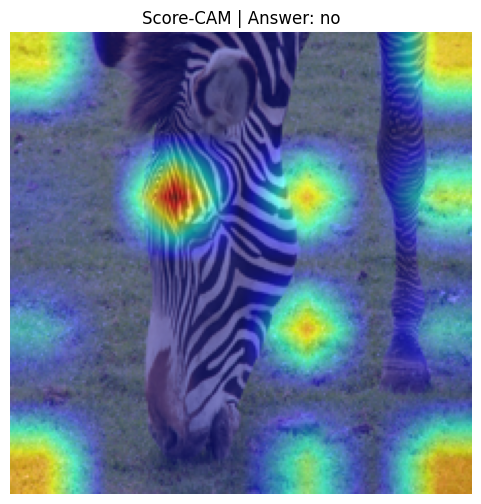

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from pytorch_grad_cam import ScoreCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

class XVQACamWrapper(torch.nn.Module):
    def __init__(self, model, input_ids, attention_mask):
        super().__init__()
        self.model = model
        self.input_ids = input_ids        # [1, seq_len]
        self.attention_mask = attention_mask  # [1, seq_len]

    def forward(self, pixel_values):
        # ScoreCAM sends batches of masked images (batch_size up to 64)
        # Expand text inputs to match that batch size
        batch_size = pixel_values.shape[0]
        input_ids = self.input_ids.expand(batch_size, -1)
        attention_mask = self.attention_mask.expand(batch_size, -1)
        return self.model(pixel_values, input_ids, attention_mask)

def swin_reshape_transform(tensor):
    batch, seq_len, hidden_dim = tensor.shape
    h = w = int(seq_len ** 0.5)
    assert h * w == seq_len, f"Cannot reshape seq_len={seq_len} into square grid"
    result = tensor.reshape(batch, h, w, hidden_dim)
    result = result.transpose(2, 3).transpose(1, 2)
    return result

def predict_and_explain(model, image, question, image_processor, tokenizer, vocab, device):
    model.eval()

    pixel_values = image_processor(images=image, return_tensors="pt").pixel_values.to(device)
    text_inputs = tokenizer(question, padding='max_length', truncation=True, max_length=40, return_tensors="pt")
    input_ids = text_inputs['input_ids'].to(device)
    attention_mask = text_inputs['attention_mask'].to(device)

    # Get prediction
    with torch.no_grad():
        logits = model(pixel_values, input_ids, attention_mask)
        pred_id = logits.argmax(dim=-1).item()

    id_to_answer = {v: k for k, v in vocab.items()}
    predicted_answer = id_to_answer.get(pred_id, "Unknown")

    # ScoreCAM
    target_layers = [model.vision_encoder.encoder.layers[-1].blocks[-1].layernorm_before]
    cam_model = XVQACamWrapper(model, input_ids, attention_mask)
    cam_model.eval()

    cam = ScoreCAM(
        model=cam_model,
        target_layers=target_layers,
        reshape_transform=swin_reshape_transform
    )

    pixel_values = pixel_values.detach().requires_grad_(True)

    with torch.amp.autocast('cuda', enabled=False):
        grayscale_cam = cam(input_tensor=pixel_values, targets=None)[0]

    rgb_img = np.float32(image.resize((224, 224))) / 255.0
    visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

    return predicted_answer, visualization

# --- RUN ---
test_image_pil = Image.open('/content/dataset/images/images/107900.jpg').convert('RGB')
test_question = "Is there a red chair in the room?"

answer, heatmap = predict_and_explain(
    model=model,
    image=test_image_pil,
    question=test_question,
    image_processor=train_dataset.image_processor,
    tokenizer=train_dataset.tokenizer,
    vocab=train_dataset.answer_to_id,
    device=device
)

print(f"Question: {test_question}")
print(f"Model Answer: {answer}")

plt.figure(figsize=(6, 6))
plt.imshow(heatmap)
plt.axis('off')
plt.title(f"Score-CAM | Answer: {answer}")
plt.show()

In [ ]:
# Save 3 good test images to Drive for report use
import shutil
os.makedirs('/content/drive/MyDrive/XVQA_project/report_samples', exist_ok=True)

for i, ex in enumerate(good_examples[:3]):
    # Copy image
    shutil.copy(
        ex['img_path'],
        f"/content/drive/MyDrive/XVQA_project/report_samples/sample_{i+1}_{ex['image_id']}.jpg"
    )
    # Save question/answer as text
    with open(f"/content/drive/MyDrive/XVQA_project/report_samples/sample_{i+1}_qa.txt", 'w') as f:
        f.write(f"Question: {ex['question']}\nAnswer: {ex['answer']}")

print("Saved to Drive. Safe to disconnect.")

Saved to Drive. Safe to disconnect.
